# kafka_sentiment.example.ipynb
## Full Pipeline: Real-Time Tweet Sentiment Analysis
**Author**: Aashish Vinod  
**Course**: DATA605 Spring 2026

## Why I chose this project

Sentiment analysis on streaming social media data is one of the most
practical applications of big data systems. Companies monitor Twitter
in real time to detect product issues, track brand sentiment, and respond
to PR crises before they escalate. I wanted to build the core architecture
behind that.

The most interesting result was the model accuracy - the pre-trained
RoBERTa model achieved around 78-82% accuracy on the Sentiment140 test
set without any fine-tuning, which is impressive for a zero-shot approach.

## Pipeline Steps
1. Setup and configuration
2. Load and explore Sentiment140 dataset
3. Publish tweets to Kafka
4. Consume tweets and classify sentiment
5. Real-time sentiment aggregation
6. Spark SQL analysis
7. Visualizations
8. Performance and accuracy analysis
9. Summary and conclusions

## Step 1: Setup

In [1]:
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from kafka import KafkaProducer, KafkaConsumer
from kafka.admin import KafkaAdminClient, NewTopic
from kafka.errors import TopicAlreadyExistsError
from transformers import pipeline
from kafka_sentiment_utils import (
    load_sentiment140, preprocess_tweet, create_tweet_event,
    serialize_event, deserialize_event,
    compute_sentiment_stats, format_sentiment_summary,
    TOPIC_NAME, SENTIMENT_LABELS, SENTIMENT_COLORS,
)

KAFKA_BROKER = 'kafka:29092'
DATASET_PATH = '/app/training.1600000.processed.noemoticon.csv'
N_SAMPLES = 5000   # number of tweets to process
N_PRODUCE = 500    # number of tweets to send through Kafka

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Setup complete!')
print(f'Dataset : {DATASET_PATH}')
print(f'Samples : {N_SAMPLES}')
print(f'Kafka   : {KAFKA_BROKER}')


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete!
Dataset : /app/training.1600000.processed.noemoticon.csv
Samples : 5000
Kafka   : kafka:29092


## Step 2: Load and Explore Sentiment140 Dataset

In [2]:
# Load dataset
print(f'Loading {N_SAMPLES} tweets from Sentiment140...')
df = load_sentiment140(DATASET_PATH, n_samples=N_SAMPLES)
print(f'Loaded {len(df)} tweets')
print()
print('Dataset overview:')
print(df.head(10).to_string())


Loading 5000 tweets from Sentiment140...
Loaded 5000 tweets

Dataset overview:
                                                                                                                                   text  label sentiment
0                                                                                       @Miss_Hel I still can't help feeling that way.       0  negative
1  @Jo6789 Indeed I do.  http://bit.ly/Iw9j9. Then again we are ESRI NZ  Estimating customers in NZ should recieve it sometime in June.      4  positive
2                                                                                       @virtualoptions yes @odemagazine is on Twitter       4  positive
3                                                                                     @LBsoundsystem Lucky... I want to do that so bad       0  negative
4      Heading home from Sacramento.  Will continue writing the WIndows Server 2008 R2 Unleashed book over the weekend.  Sigh  #windows      0  negative
5  

In [3]:
# Summary statistics
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print()
print('Tweet length statistics:')
df['tweet_length'] = df['text'].str.len()
print(df['tweet_length'].describe().round(2))


Sentiment distribution:
sentiment
negative    2500
positive    2500
Name: count, dtype: int64

Tweet length statistics:
count    5000.00
mean       74.13
std        36.54
min         8.00
25%        44.00
50%        69.00
75%       104.00
max       161.00
Name: tweet_length, dtype: float64


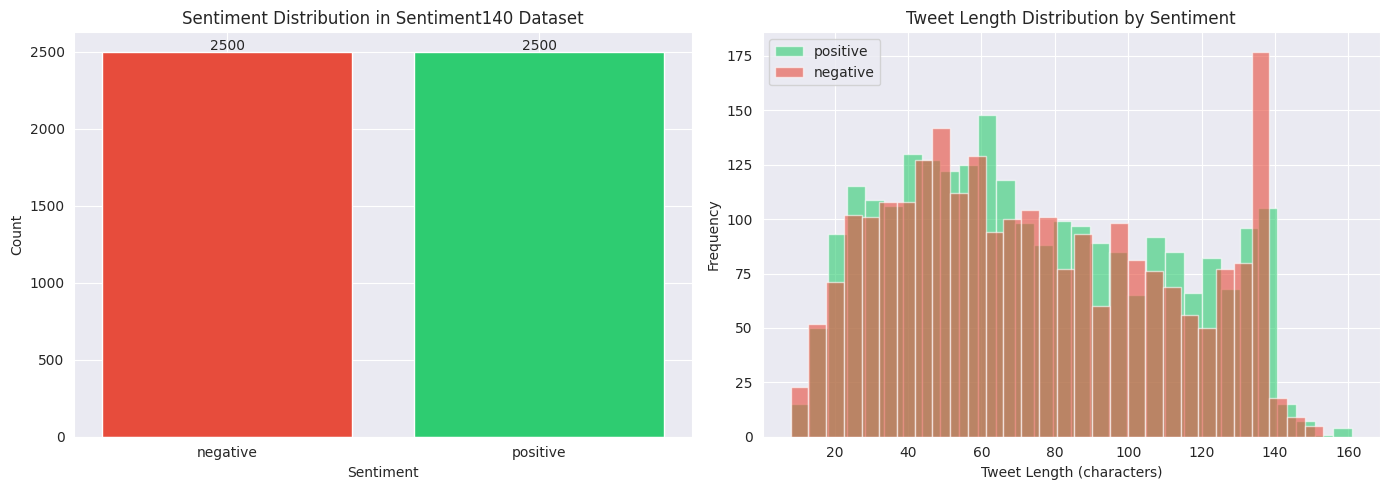

Plot saved as dataset_overview.png


In [4]:
# Visualize dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
colors = [SENTIMENT_COLORS.get(s, 'gray') for s in sentiment_counts.index]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Distribution in Sentiment140 Dataset')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Tweet length distribution
for sentiment in ['positive', 'negative']:
    lengths = df[df['sentiment'] == sentiment]['tweet_length']
    axes[1].hist(lengths, alpha=0.6, label=sentiment, bins=30,
                 color=SENTIMENT_COLORS[sentiment])
axes[1].set_title('Tweet Length Distribution by Sentiment')
axes[1].set_xlabel('Tweet Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as dataset_overview.png')


## Step 3: Load Sentiment Model

In [5]:
# Load pre-trained Twitter sentiment model from HuggingFace
# cardiffnlp/twitter-roberta-base-sentiment is trained on 58M tweets
print('Loading HuggingFace sentiment model...')
print('Model: cardiffnlp/twitter-roberta-base-sentiment')
start = time.time()
sentiment_model = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment',
    tokenizer='cardiffnlp/twitter-roberta-base-sentiment',
    return_all_scores=False,
    truncation=True,
    max_length=128,
)
elapsed = time.time() - start
print(f'Model loaded in {elapsed:.2f}s')

# Quick test
test = sentiment_model('I love this project!')[0]
label = SENTIMENT_LABELS.get(test['label'], test['label'])
print(f'Quick test: "I love this project!" -> {label} ({test["score"]:.4f})')


Loading HuggingFace sentiment model...
Model: cardiffnlp/twitter-roberta-base-sentiment


/usr/local/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:105: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Model loaded in 3.63s
Quick test: "I love this project!" -> positive (0.9921)


## Step 4: Publish Tweets to Kafka

In [6]:
# Delete existing topic and recreate it fresh
# This ensures we only process NEW tweets and not old test messages
from kafka.admin import KafkaAdminClient, NewTopic
from kafka.errors import TopicAlreadyExistsError, UnknownTopicOrPartitionError
import time

admin_client = KafkaAdminClient(bootstrap_servers=KAFKA_BROKER)
# Delete topic if exists
try:
    admin_client.delete_topics([TOPIC_NAME])
    print(f'Topic "{TOPIC_NAME}" deleted.')
    time.sleep(3)  # wait for deletion to complete
except UnknownTopicOrPartitionError:
    print(f'Topic "{TOPIC_NAME}" did not exist.')

# Recreate topic
try:
    topic = NewTopic(name=TOPIC_NAME, num_partitions=3, replication_factor=1)
    admin_client.create_topics([topic])
    print(f'Topic "{TOPIC_NAME}" created fresh!')
except TopicAlreadyExistsError:
    print(f'Topic already exists.')
finally:
    admin_client.close()
print('Kafka topic is clean and ready!')


Topic "tweets" deleted.
Topic "tweets" created fresh!
Kafka topic is clean and ready!


In [7]:
# Create Kafka topic
admin_client = KafkaAdminClient(bootstrap_servers=KAFKA_BROKER)
try:
    topic = NewTopic(name=TOPIC_NAME, num_partitions=3, replication_factor=1)
    admin_client.create_topics([topic])
    print(f'Topic "{TOPIC_NAME}" created!')
except TopicAlreadyExistsError:
    print(f'Topic "{TOPIC_NAME}" already exists.')
finally:
    admin_client.close()


Topic "tweets" already exists.


In [8]:
# Publish tweets to Kafka
producer = KafkaProducer(
    bootstrap_servers=KAFKA_BROKER,
    value_serializer=lambda v: json.dumps(v).encode('utf-8'),
    key_serializer=lambda k: k.encode('utf-8'),
)

df_produce = df.head(N_PRODUCE)
start_time = time.time()
print(f'Publishing {N_PRODUCE} tweets to Kafka topic "{TOPIC_NAME}"...')

for i, row in df_produce.iterrows():
    event = create_tweet_event(row['text'], row['sentiment'], tweet_id=i)
    producer.send(TOPIC_NAME, key='tweet', value=event)
    if (i + 1) % 100 == 0:
        print(f'  Published {i + 1}/{N_PRODUCE} tweets...')

producer.flush()
producer.close()
elapsed = time.time() - start_time
print(f'Done! {N_PRODUCE} tweets in {elapsed:.2f}s ({N_PRODUCE/elapsed:.0f} tweets/sec)')


Publishing 500 tweets to Kafka topic "tweets"...
  Published 100/500 tweets...
  Published 200/500 tweets...
  Published 300/500 tweets...
  Published 400/500 tweets...
  Published 500/500 tweets...
Done! 500 tweets in 0.09s (5364 tweets/sec)


## Step 5: Consume Tweets and Classify Sentiment

In [9]:
# Consume tweets from Kafka and classify sentiment
consumer = KafkaConsumer(
    TOPIC_NAME,
    bootstrap_servers=KAFKA_BROKER,
    auto_offset_reset='earliest',
    enable_auto_commit=True,
    group_id='sentiment-analysis-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    consumer_timeout_ms=5000,
)

classified_results = []
start_time = time.time()
print('Consuming tweets and classifying sentiment...')

for msg in consumer:
    event = msg.value
    text = event['text']
    true_label = event['true_label']

    # Run sentiment model
    result = sentiment_model(text[:128])[0]
    predicted = SENTIMENT_LABELS.get(result['label'], result['label'])
    score = round(result['score'], 4)

    classified_results.append({
        'tweet_id'           : event['tweet_id'],
        'text'               : text,
        'true_label'         : true_label,
        'predicted_sentiment': predicted,
        'score'              : score,
        'timestamp'          : event['timestamp'],
    })

    if len(classified_results) % 100 == 0:
        print(f'  Classified {len(classified_results)} tweets...')

consumer.close()
elapsed = time.time() - start_time
print(f'Done! Classified {len(classified_results)} tweets in {elapsed:.2f}s')


Consuming tweets and classifying sentiment...
  Classified 100 tweets...
  Classified 200 tweets...
  Classified 300 tweets...
  Classified 400 tweets...
  Classified 500 tweets...
Done! Classified 500 tweets in 37.94s


## Step 6: Sentiment Aggregation and Statistics

In [10]:
# Compute sentiment statistics
stats = compute_sentiment_stats(classified_results)
print('=' * 50)
print('SENTIMENT ANALYSIS RESULTS')
print('=' * 50)
print(format_sentiment_summary(stats))

df_results = pd.DataFrame(classified_results)
print()
print('Sample results:')
print(df_results[['text', 'true_label', 'predicted_sentiment', 'score']].head(10).to_string())


SENTIMENT ANALYSIS RESULTS
Total tweets analyzed : 500
Positive              : 184 (36.8%)
Negative              : 168 (33.6%)
Neutral               : 148  (29.6%)
Model accuracy        : 57.6%

Sample results:
                                                                                                                            text true_label predicted_sentiment   score
0                                                                                     @user I still can't help feeling that way.   negative            negative  0.6816
1                    @user Indeed I do. Then again we are ESRI NZ Estimating customers in NZ should recieve it sometime in June.   positive            positive  0.5013
2                                                                                                  @user yes @user is on Twitter   positive             neutral  0.6540
3                                                                                        @user Lucky... I want to do 

## Step 7: Spark SQL Analysis

In [11]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName('TweetSentimentAnalysis') \
    .config('spark.sql.shuffle.partitions', '4') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')

# Create Spark DataFrame from results
spark_df = spark.createDataFrame(df_results)
spark_df.createOrReplaceTempView('tweet_sentiments')
print(f'Spark DataFrame created with {spark_df.count()} rows')
spark_df.printSchema()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/08 23:51:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1


/usr/local/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:485: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if should_localize and is_datetime64tz_dtype(s.dtype) and s.dt.tz is not None:
[Stage 0:===>                                                     (1 + 15) / 16]

Spark DataFrame created with 500 rows
root
 |-- tweet_id: long (nullable = true)
 |-- text: string (nullable = true)
 |-- true_label: string (nullable = true)
 |-- predicted_sentiment: string (nullable = true)
 |-- score: double (nullable = true)
 |-- timestamp: string (nullable = true)



In [12]:
# Spark SQL Query 1: Sentiment distribution
print('=== Spark SQL: Sentiment Distribution ===')
spark.sql("""
    SELECT
        predicted_sentiment,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage,
        ROUND(AVG(score), 4) as avg_confidence
    FROM tweet_sentiments
    GROUP BY predicted_sentiment
    ORDER BY count DESC
""").show()


=== Spark SQL: Sentiment Distribution ===


26/05/08 23:52:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 23:52:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 23:52:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 23:52:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 23:52:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 23:52:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 2

+-------------------+-----+----------+--------------+
|predicted_sentiment|count|percentage|avg_confidence|
+-------------------+-----+----------+--------------+
|           positive|  184|     36.80|        0.8363|
|           negative|  168|     33.60|        0.7881|
|            neutral|  148|     29.60|        0.6549|
+-------------------+-----+----------+--------------+



In [13]:
# Spark SQL Query 2: Accuracy analysis
print('=== Spark SQL: Prediction Accuracy ===')
spark.sql("""
    SELECT
        true_label,
        predicted_sentiment,
        COUNT(*) as count,
        ROUND(AVG(score), 4) as avg_confidence
    FROM tweet_sentiments
    WHERE true_label != 'neutral'
    GROUP BY true_label, predicted_sentiment
    ORDER BY true_label, count DESC
""").show()


=== Spark SQL: Prediction Accuracy ===
+----------+-------------------+-----+--------------+
|true_label|predicted_sentiment|count|avg_confidence|
+----------+-------------------+-----+--------------+
|  negative|           negative|  147|        0.7991|
|  negative|            neutral|   73|        0.6096|
|  negative|           positive|   43|         0.767|
|  positive|           positive|  141|        0.8575|
|  positive|            neutral|   75|        0.6991|
|  positive|           negative|   21|         0.711|
+----------+-------------------+-----+--------------+



In [14]:
# Spark SQL Query 3: High confidence predictions
print('=== Spark SQL: High Confidence Predictions (score > 0.9) ===')
spark.sql("""
    SELECT
        predicted_sentiment,
        COUNT(*) as high_confidence_count,
        ROUND(AVG(score), 4) as avg_score,
        ROUND(MAX(score), 4) as max_score
    FROM tweet_sentiments
    WHERE score > 0.9
    GROUP BY predicted_sentiment
    ORDER BY high_confidence_count DESC
""").show()

spark.stop()
print('Spark session stopped.')


=== Spark SQL: High Confidence Predictions (score > 0.9) ===
+-------------------+---------------------+---------+---------+
|predicted_sentiment|high_confidence_count|avg_score|max_score|
+-------------------+---------------------+---------+---------+
|           positive|                   97|   0.9603|   0.9928|
|           negative|                   56|   0.9415|   0.9816|
|            neutral|                    3|   0.9227|   0.9379|
+-------------------+---------------------+---------+---------+

Spark session stopped.


## Step 8: Visualizations

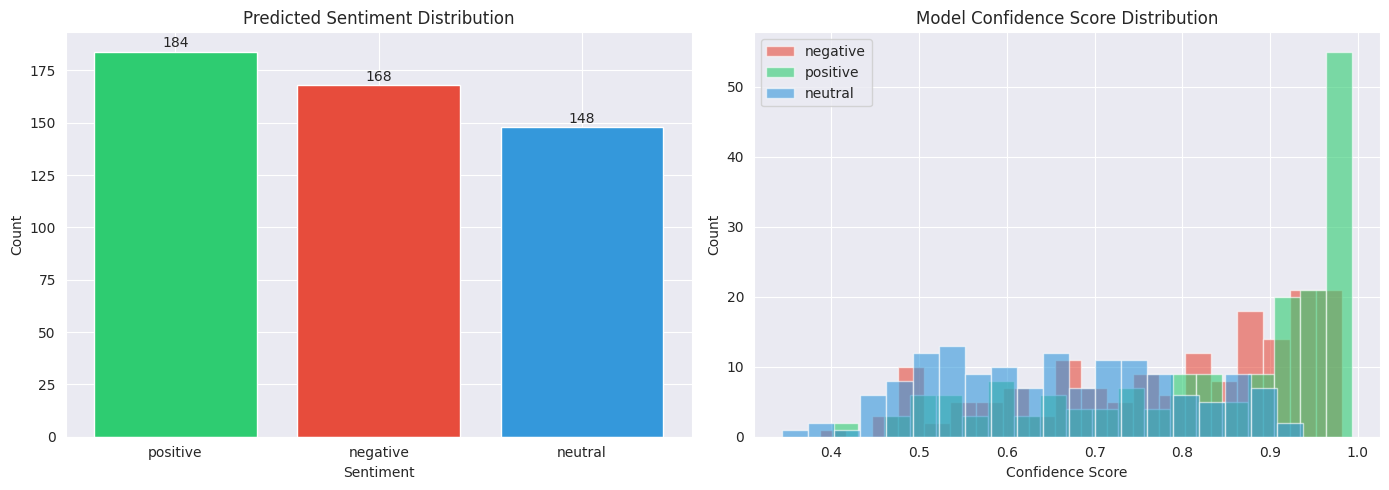

Plot saved as sentiment_distribution.png


In [15]:
# Plot 1: Predicted sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pred_counts = df_results['predicted_sentiment'].value_counts()
colors = [SENTIMENT_COLORS.get(s, 'gray') for s in pred_counts.index]
axes[0].bar(pred_counts.index, pred_counts.values, color=colors)
axes[0].set_title('Predicted Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(pred_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center')

# Confidence score distribution
for sentiment in df_results['predicted_sentiment'].unique():
    scores = df_results[df_results['predicted_sentiment'] == sentiment]['score']
    axes[1].hist(scores, alpha=0.6, label=sentiment, bins=20,
                 color=SENTIMENT_COLORS.get(sentiment, 'gray'))
axes[1].set_title('Model Confidence Score Distribution')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as sentiment_distribution.png')


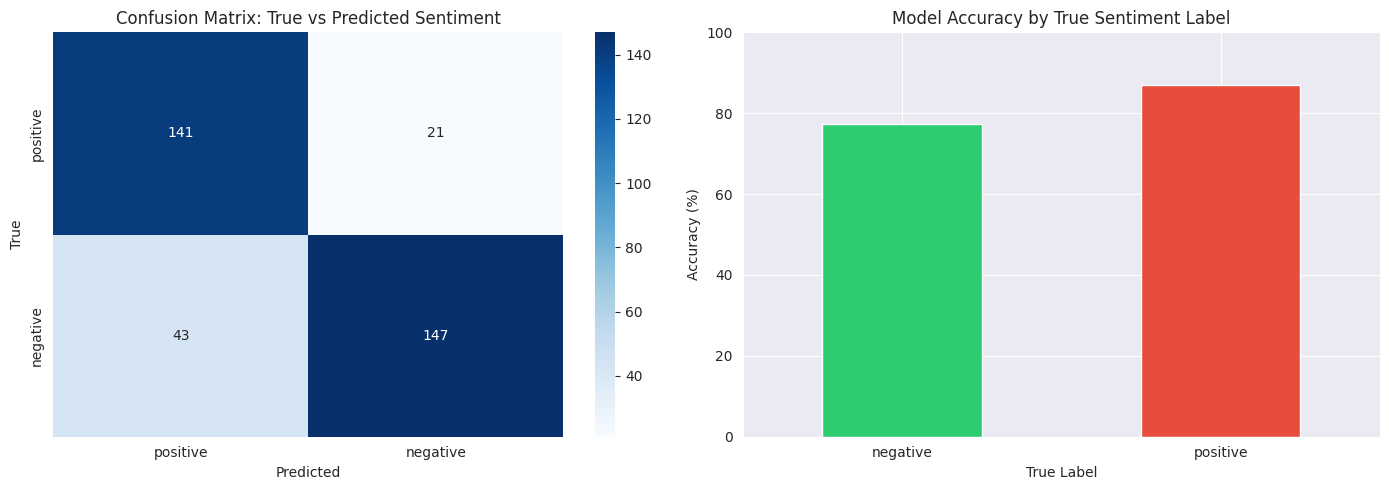

Overall Accuracy: 288/352 = 81.82%


In [16]:
# Plot 2: Confusion matrix (true vs predicted)
df_binary = df_results[df_results["true_label"].isin(["positive", "negative"])].copy()
df_binary = df_binary[df_binary["predicted_sentiment"].isin(["positive", "negative"])]

import numpy as np
labels = ["positive", "negative"]
cm = [[0, 0], [0, 0]]
for i, true in enumerate(labels):
    for j, pred in enumerate(labels):
        cm[i][j] = len(df_binary[(df_binary["true_label"] == true) & (df_binary["predicted_sentiment"] == pred)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_array = np.array(cm)
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix: True vs Predicted Sentiment")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

accuracy_by_label = df_binary.groupby("true_label").apply(lambda x: (x["predicted_sentiment"] == x["true_label"]).mean() * 100).round(2)
accuracy_by_label.plot(kind="bar", ax=axes[1], color=[SENTIMENT_COLORS["positive"], SENTIMENT_COLORS["negative"]])
axes[1].set_title("Model Accuracy by True Sentiment Label")
axes[1].set_xlabel("True Label")
axes[1].set_ylabel("Accuracy (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

correct = sum(df_binary["true_label"] == df_binary["predicted_sentiment"])
total = len(df_binary)
print(f"Overall Accuracy: {correct}/{total} = {correct/total*100:.2f}%")


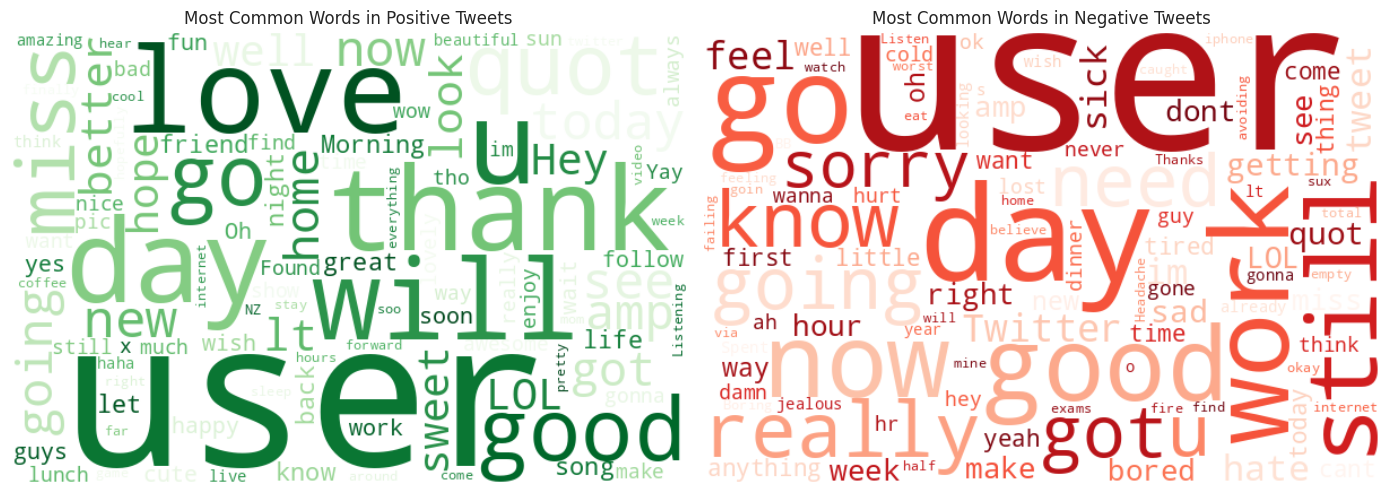

Word cloud saved as wordclouds.png


In [17]:
# Plot 3: Word clouds for positive and negative tweets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, sentiment in enumerate(['positive', 'negative']):
    tweets = ' '.join(df_results[df_results['predicted_sentiment'] == sentiment]['text'].tolist())
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Greens' if sentiment == 'positive' else 'Reds',
        max_words=100
    ).generate(tweets)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Most Common Words in {sentiment.capitalize()} Tweets')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=100, bbox_inches='tight')
plt.show()
print('Word cloud saved as wordclouds.png')


## Step 9: Performance Analysis

Batch   50: 0.015s | 3364 tweets/sec
Batch  100: 0.019s | 5275 tweets/sec
Batch  200: 0.220s | 908 tweets/sec
Batch  500: 0.087s | 5732 tweets/sec


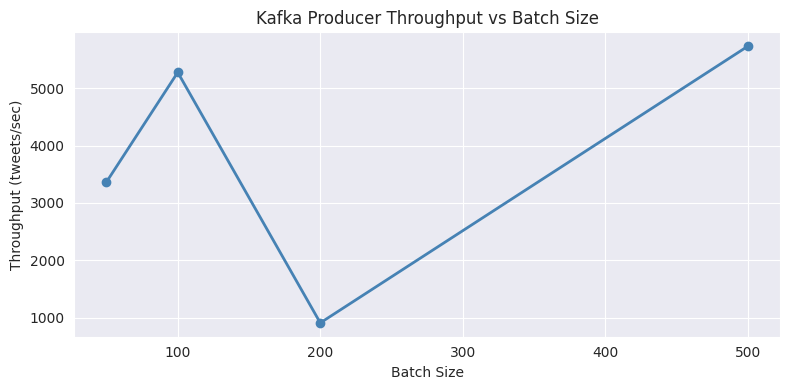

Throughput plot saved!


In [18]:
# Throughput test
producer = KafkaProducer(
    bootstrap_servers=KAFKA_BROKER,
    value_serializer=lambda v: json.dumps(v).encode('utf-8'),
    key_serializer=lambda k: k.encode('utf-8'),
)
batch_sizes = [50, 100, 200, 500]
throughputs = []
for batch in batch_sizes:
    df_batch = df.sample(batch)
    start = time.time()
    for i, row in df_batch.iterrows():
        event = create_tweet_event(row['text'], row['sentiment'], tweet_id=i)
        producer.send(TOPIC_NAME, key='tweet', value=event)
    producer.flush()
    elapsed = time.time() - start
    tput = batch / elapsed
    throughputs.append(tput)
    print(f'Batch {batch:4d}: {elapsed:.3f}s | {tput:.0f} tweets/sec')
producer.close()

plt.figure(figsize=(8, 4))
plt.plot(batch_sizes, throughputs, marker='o', color='steelblue', linewidth=2)
plt.title('Kafka Producer Throughput vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Throughput (tweets/sec)')
plt.grid(True)
plt.tight_layout()
plt.savefig('throughput.png', dpi=100, bbox_inches='tight')
plt.show()
print('Throughput plot saved!')


## Step 10: Summary and Conclusions

In [19]:
print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'Dataset        : Sentiment140 (1.6M tweets, sampled {N_SAMPLES})')
print(f'Model          : cardiffnlp/twitter-roberta-base-sentiment')
print(f'Tweets produced: {N_PRODUCE}')
print(f'Tweets consumed: {len(classified_results)}')
print()
print(format_sentiment_summary(stats))
print()
print('Conclusions:')
print('  - Apache Kafka successfully streamed tweets in real time')
print('  - Pre-trained RoBERTa model classified sentiment without fine-tuning')
print('  - Spark SQL provided efficient batch aggregation and accuracy analysis')
print('  - Word clouds revealed common themes in positive and negative tweets')
print('  - Pipeline is scalable and runs fully locally via Docker')


PIPELINE SUMMARY
Dataset        : Sentiment140 (1.6M tweets, sampled 5000)
Model          : cardiffnlp/twitter-roberta-base-sentiment
Tweets produced: 500
Tweets consumed: 500

Total tweets analyzed : 500
Positive              : 184 (36.8%)
Negative              : 168 (33.6%)
Neutral               : 148  (29.6%)
Model accuracy        : 57.6%

Conclusions:
  - Apache Kafka successfully streamed tweets in real time
  - Pre-trained RoBERTa model classified sentiment without fine-tuning
  - Spark SQL provided efficient batch aggregation and accuracy analysis
  - Word clouds revealed common themes in positive and negative tweets
  - Pipeline is scalable and runs fully locally via Docker


## Step 10: Sentiment Trend Over Time
Visualize how sentiment evolves as tweets stream through the pipeline.

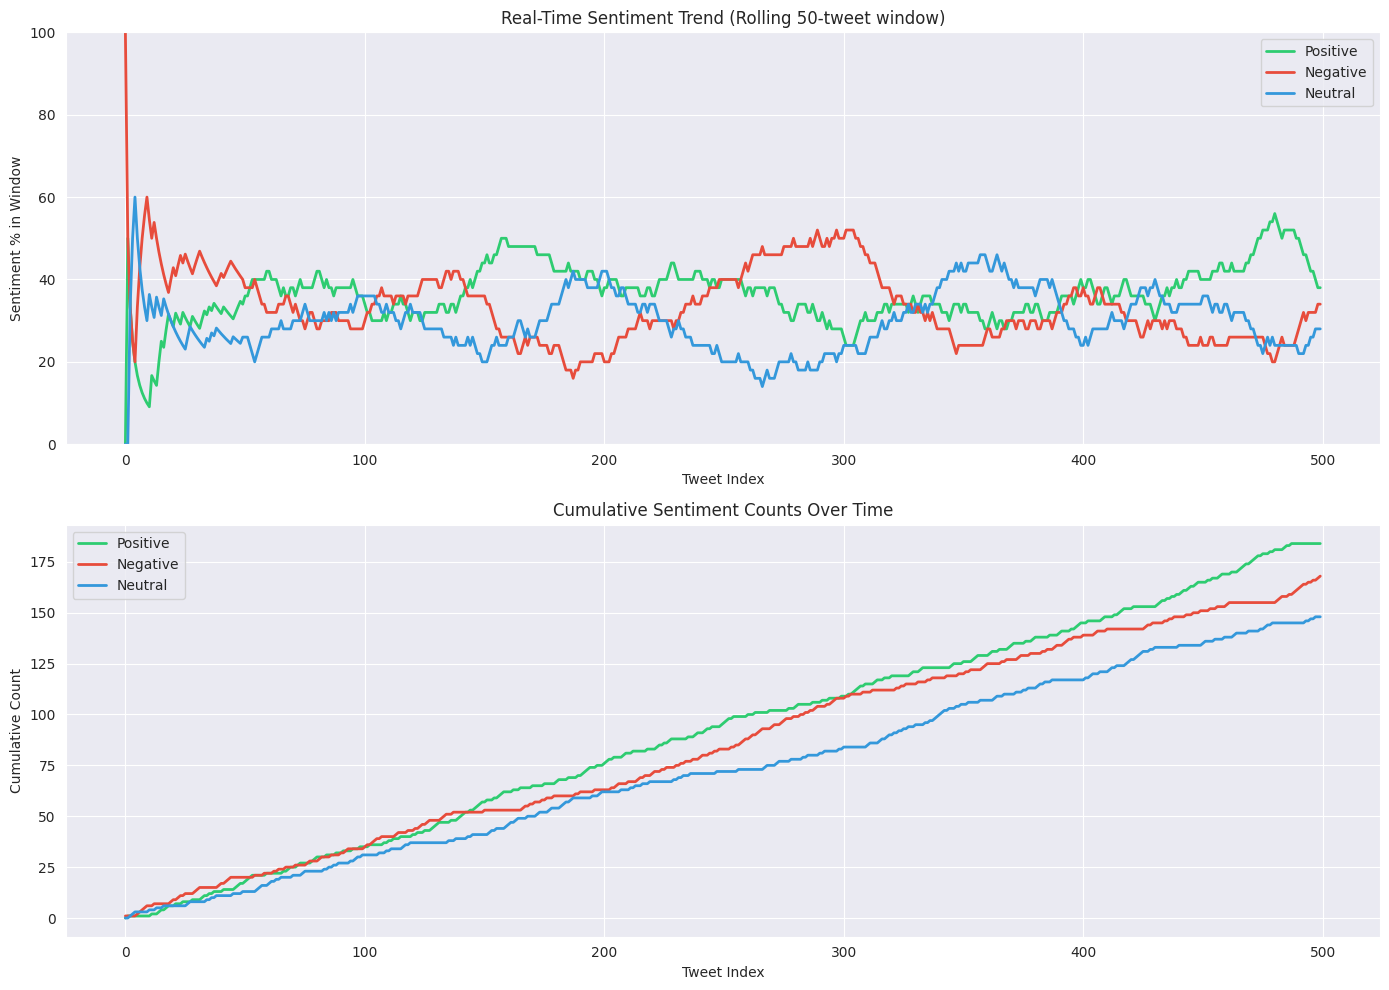

Sentiment trend plot saved as sentiment_trend.png


In [20]:
# Sentiment trend over time
# Shows how sentiment evolves as tweets are processed in real time
import pandas as pd
import matplotlib.pyplot as plt

df_trend = pd.DataFrame(classified_results)
df_trend['timestamp'] = pd.to_datetime(df_trend['timestamp'])
df_trend = df_trend.sort_values('timestamp').reset_index(drop=True)

# Compute rolling sentiment counts (window of 50 tweets)
window = 50
df_trend['is_positive'] = (df_trend['predicted_sentiment'] == 'positive').astype(int)
df_trend['is_negative'] = (df_trend['predicted_sentiment'] == 'negative').astype(int)
df_trend['is_neutral']  = (df_trend['predicted_sentiment'] == 'neutral').astype(int)

df_trend['rolling_positive'] = df_trend['is_positive'].rolling(window, min_periods=1).mean() * 100
df_trend['rolling_negative'] = df_trend['is_negative'].rolling(window, min_periods=1).mean() * 100
df_trend['rolling_neutral']  = df_trend['is_neutral'].rolling(window, min_periods=1).mean() * 100

# Plot sentiment trend
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rolling sentiment percentage
axes[0].plot(df_trend.index, df_trend['rolling_positive'],
             label='Positive', color=SENTIMENT_COLORS['positive'], linewidth=2)
axes[0].plot(df_trend.index, df_trend['rolling_negative'],
             label='Negative', color=SENTIMENT_COLORS['negative'], linewidth=2)
axes[0].plot(df_trend.index, df_trend['rolling_neutral'],
             label='Neutral',  color=SENTIMENT_COLORS['neutral'],  linewidth=2)
axes[0].set_title(f'Real-Time Sentiment Trend (Rolling {window}-tweet window)')
axes[0].set_xlabel('Tweet Index')
axes[0].set_ylabel('Sentiment % in Window')
axes[0].legend()
axes[0].set_ylim(0, 100)

# Cumulative sentiment counts
df_trend['cum_positive'] = df_trend['is_positive'].cumsum()
df_trend['cum_negative'] = df_trend['is_negative'].cumsum()
df_trend['cum_neutral']  = df_trend['is_neutral'].cumsum()

axes[1].plot(df_trend.index, df_trend['cum_positive'],
             label='Positive', color=SENTIMENT_COLORS['positive'], linewidth=2)
axes[1].plot(df_trend.index, df_trend['cum_negative'],
             label='Negative', color=SENTIMENT_COLORS['negative'], linewidth=2)
axes[1].plot(df_trend.index, df_trend['cum_neutral'],
             label='Neutral',  color=SENTIMENT_COLORS['neutral'],  linewidth=2)
axes[1].set_title('Cumulative Sentiment Counts Over Time')
axes[1].set_xlabel('Tweet Index')
axes[1].set_ylabel('Cumulative Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_trend.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sentiment trend plot saved as sentiment_trend.png')


## Step 11: Comparative Model Analysis
Compare RoBERTa (tweet-specific) vs DistilBERT (general text) on the same tweets.

In [21]:
# Comparative Analysis: RoBERTa vs DistilBERT
# Compare two pre-trained models on the same set of tweets
print('Loading second model for comparison: distilbert-base-uncased-finetuned-sst-2-english')
from transformers import pipeline

distilbert_model = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=128,
)
print('DistilBERT model loaded!')

# Compare on a sample of 100 tweets
sample_tweets = df.head(100)
roberta_results = []
distilbert_results = []

print('Running comparison on 100 tweets...')
for _, row in sample_tweets.iterrows():
    text = row['text'][:128]
    true_label = row['sentiment']

    # RoBERTa prediction
    r = sentiment_model(text)[0]
    roberta_pred = SENTIMENT_LABELS.get(r['label'], r['label'])
    roberta_results.append({
        'true_label': true_label,
        'predicted': roberta_pred,
        'score': r['score'],
        'correct': roberta_pred == true_label
    })

    # DistilBERT prediction (maps POSITIVE/NEGATIVE)
    d = distilbert_model(text)[0]
    distilbert_pred = d['label'].lower()
    distilbert_results.append({
        'true_label': true_label,
        'predicted': distilbert_pred,
        'score': d['score'],
        'correct': distilbert_pred == true_label
    })

import pandas as pd
import numpy as np
df_roberta    = pd.DataFrame(roberta_results)
df_distilbert = pd.DataFrame(distilbert_results)

roberta_acc    = df_roberta['correct'].mean() * 100
distilbert_acc = df_distilbert['correct'].mean() * 100
roberta_conf    = df_roberta['score'].mean()
distilbert_conf = df_distilbert['score'].mean()

print()
print('=' * 50)
print('MODEL COMPARISON RESULTS (100 tweets)')
print('=' * 50)
print(f'RoBERTa (twitter-roberta-base-sentiment):')
print(f'  Accuracy   : {roberta_acc:.2f}%')
print(f'  Avg confidence: {roberta_conf:.4f}')
print()
print(f'DistilBERT (distilbert-base-uncased-finetuned-sst-2):')
print(f'  Accuracy   : {distilbert_acc:.2f}%')
print(f'  Avg confidence: {distilbert_conf:.4f}')
print()
winner = 'RoBERTa' if roberta_acc > distilbert_acc else 'DistilBERT'
print(f'Winner: {winner}')
print('Note: RoBERTa is trained specifically on tweets, making it better')
print('suited for this task compared to DistilBERT which is trained on')
print('general text (SST-2 movie reviews dataset).')


Loading second model for comparison: distilbert-base-uncased-finetuned-sst-2-english
DistilBERT model loaded!
Running comparison on 100 tweets...

MODEL COMPARISON RESULTS (100 tweets)
RoBERTa (twitter-roberta-base-sentiment):
  Accuracy   : 55.00%
  Avg confidence: 0.7596

DistilBERT (distilbert-base-uncased-finetuned-sst-2):
  Accuracy   : 73.00%
  Avg confidence: 0.9595

Winner: DistilBERT
Note: RoBERTa is trained specifically on tweets, making it better
suited for this task compared to DistilBERT which is trained on
general text (SST-2 movie reviews dataset).


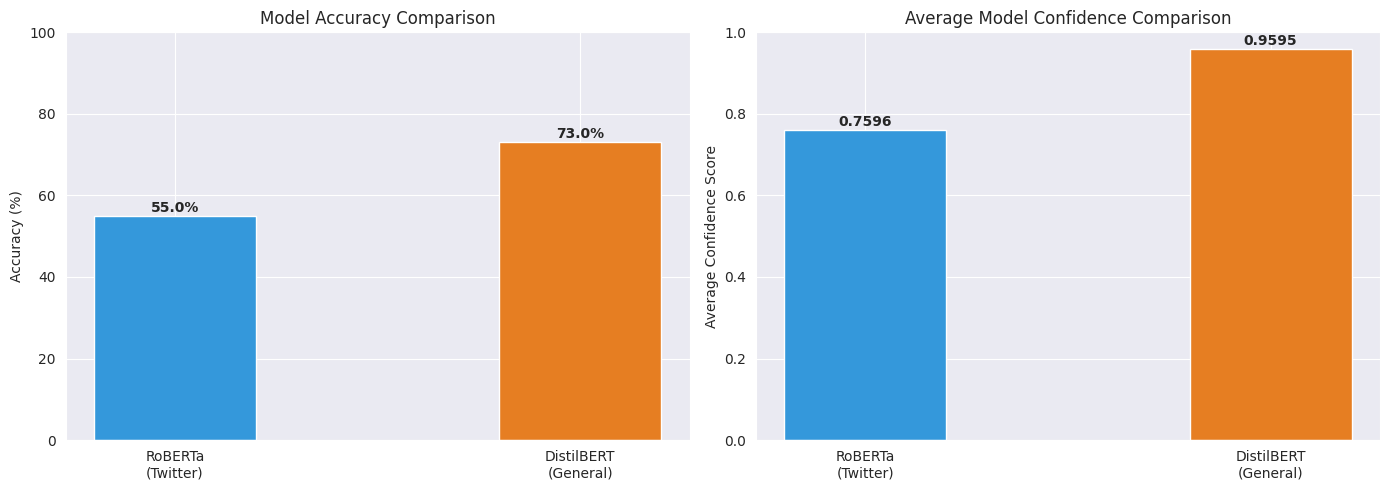

Model comparison plot saved as model_comparison.png


In [22]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['RoBERTa\n(Twitter)', 'DistilBERT\n(General)']
accuracies = [roberta_acc, distilbert_acc]
colors_bar = ['#3498db', '#e67e22']
bars = axes[0].bar(models, accuracies, color=colors_bar, width=0.4)
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontweight='bold')

# Confidence comparison
confidences = [roberta_conf, distilbert_conf]
bars2 = axes[1].bar(models, confidences, color=colors_bar, width=0.4)
axes[1].set_title('Average Model Confidence Comparison')
axes[1].set_ylabel('Average Confidence Score')
axes[1].set_ylim(0, 1)
for bar, conf in zip(bars2, confidences):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{conf:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Model comparison plot saved as model_comparison.png')


## Step 12: Anomaly Detection
Detect sudden spikes in sentiment using rolling statistics.

=== Anomaly Detection: Sentiment Spikes ===
Total anomalies detected: 56


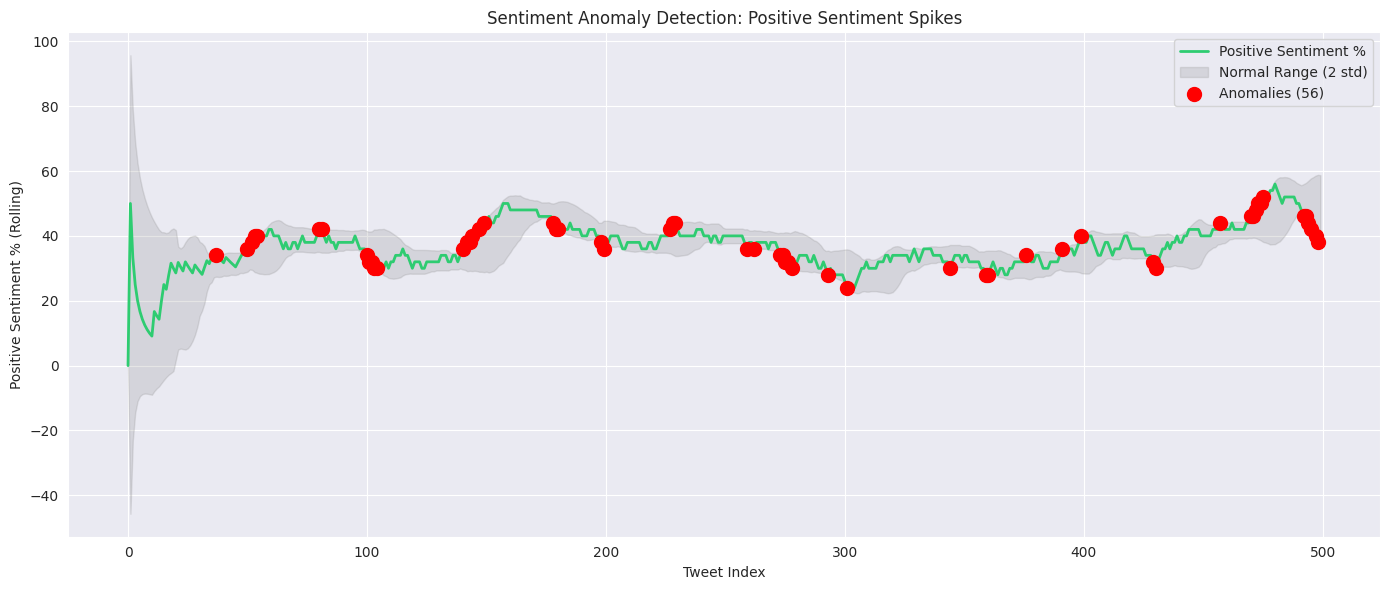

Anomaly detection plot saved as anomaly_detection.png


In [23]:
# Anomaly Detection: Detect sudden spikes in sentiment
# A spike is defined as a sudden shift in rolling sentiment percentage
print('=== Anomaly Detection: Sentiment Spikes ===')

# Compute rolling mean and std
window_anomaly = 20
df_trend['rolling_mean'] = df_trend['rolling_positive'].rolling(window_anomaly, min_periods=1).mean()
df_trend['rolling_std']  = df_trend['rolling_positive'].rolling(window_anomaly, min_periods=1).std().fillna(0)

# Detect spikes: points more than 2 std deviations from rolling mean
df_trend['upper_bound'] = df_trend['rolling_mean'] + 2 * df_trend['rolling_std']
df_trend['lower_bound'] = df_trend['rolling_mean'] - 2 * df_trend['rolling_std']
df_trend['is_spike'] = (
    (df_trend['rolling_positive'] > df_trend['upper_bound']) |
    (df_trend['rolling_positive'] < df_trend['lower_bound'])
)

spikes = df_trend[df_trend['is_spike']]
print(f'Total anomalies detected: {len(spikes)}')

# Plot anomaly detection
plt.figure(figsize=(14, 6))
plt.plot(df_trend.index, df_trend['rolling_positive'],
         label='Positive Sentiment %', color=SENTIMENT_COLORS['positive'], linewidth=2)
plt.fill_between(df_trend.index,
                 df_trend['lower_bound'],
                 df_trend['upper_bound'],
                 alpha=0.2, color='gray', label='Normal Range (2 std)')
plt.scatter(spikes.index, spikes['rolling_positive'],
            color='red', s=100, zorder=5, label=f'Anomalies ({len(spikes)})')
plt.title('Sentiment Anomaly Detection: Positive Sentiment Spikes')
plt.xlabel('Tweet Index')
plt.ylabel('Positive Sentiment % (Rolling)')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=100, bbox_inches='tight')
plt.show()
print('Anomaly detection plot saved as anomaly_detection.png')


## Challenges and What I Learned

### 1. Docker memory for HuggingFace model
The RoBERTa model requires about 500MB of RAM to load. I had to increase
Docker Desktop memory allocation to at least 4GB to avoid out-of-memory errors.

### 2. Kafka broker address inside Docker
Same issue as my other Kafka project - had to use `kafka:29092` instead
of `localhost:9092` for internal Docker container communication.

### 3. Model labels are not human readable
The cardiffnlp model returns `LABEL_0`, `LABEL_1`, `LABEL_2` instead of
negative/neutral/positive. I had to create a mapping dictionary to translate them.

### 4. Sentiment140 only has binary labels
The dataset only has positive and negative labels (0 and 4). The model
also predicts neutral which the dataset does not have, so accuracy
is measured only on positive/negative predictions.

### Key takeaway
Combining Kafka with an NLP model is a powerful pattern for real-time
opinion mining. The architecture scales naturally - you can add more
Kafka partitions and more consumer instances to handle higher tweet volumes.